# Initialiazation Packages

In [1]:
import numpy as np
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from dataclasses import dataclass

# -------------------------------------------------------------------
# Units:
# Use energies/frequencies in ANGULAR units.
# Convenient choice: time in ns, energies in rad/ns.
# Then 1 GHz corresponds to 2*pi rad/ns.
# -------------------------------------------------------------------
GHz = 2.0 * np.pi  # multiply a value in GHz by this

## Fluxonium Potential

$$
    U(\varphi)=\frac{E_L}{2}(\phi)^2-E_J\cos(\phi-\varphi_{\mathrm{ext}}(t))
$$

In [2]:
import sys
sys.path.append('../src')  # add the src directory to the Python path
from fluxonium_classical import FluxoniumParams, energy_balance_from_augmented_solution, make_initial_conditions, potential, find_potential_extrema

"""
print("Defining parameters...")
param = FluxoniumParams(
    EC=0.8308,
    EJ=4.167,
    EL=1.203,
    phi_ext0= 0.5,
    omega_d=2.0,
    A_charge=0.0,
    A_flux=0.0,
)
display(param)
"""
param = FluxoniumParams(
    EC=1.0,
    EJ=3.6,
    EL=0.7,
    phi_ext0= 0.5*2*np.pi,
    omega_d=2.0,
    A_charge=0.0,
    A_flux=0.0,
)
display(param)

FluxoniumParams(EC=1.0, EJ=3.6, EL=0.7, phi_ext0=3.141592653589793, omega_d=2.0, A_charge=0.0, A_flux=0.0, gauge='inductive')

In [3]:
print("Defining potential plotting function...")
def plot_fluxonium_potential(
    p: FluxoniumParams,
    phi_min=-10*np.pi,
    phi_max=10*np.pi,
    npoints=400,
    subtract_min=False,
    ax=None,
):
    """
    Plot the undriven fluxonium potential

        U(phi) = EL/2 * (phi - phi_ext)^2 - EJ cos(phi)

    Parameters
    ----------
    p : FluxoniumParams
        Fluxonium parameters
    phi_min, phi_max : float
        Range of phi to plot.
    npoints : int
        Number of grid points.
    subtract_min : bool
        If True, shift the potential so its minimum value is zero.
    ax : matplotlib axis or None
        If None, create a new figure.
    """
    phi = np.linspace(phi_min, phi_max, npoints)
    U = potential(phi, p)

    if subtract_min:
        U_min = np.min(U)
        U = U - U_min
        

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4.5))

    ax.plot(phi - p.phi_ext0, U, lw=2)
    ax.set_xlabel(r'$\phi$ - $\phi_{ext}$')
    ax.set_ylabel(r'$U(\phi)$')
    ax.set_title('Undriven fluxonium potential')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-12., 12.)
    ax.set_ylim(-4, 60.)

    return phi, U, U_min, ax

Defining potential plotting function...


In [4]:
def plot_fluxonium_potential_with_extrema(
    p: FluxoniumParams,
    phi_min=-4*np.pi,
    phi_max=4*np.pi,
    npoints=4000,
    subtract_min=False,
    ):
    
    phi, U, U_min, ax = plot_fluxonium_potential(
        p,
        phi_min=phi_min,
        phi_max=phi_max,
        npoints=npoints,
        subtract_min=subtract_min,
    )

    minima, maxima = find_potential_extrema(param)
    
    if len(minima) > 0:
        ax.plot(minima[:, 0] - p.phi_ext0, minima[:, 1] - U_min, 'o', label='minima')

    if len(maxima) > 0:
        ax.plot(maxima[:, 0] - p.phi_ext0, maxima[:, 1] - U_min, 's', label='maxima')

    ax.legend()
    return phi, U, minima, maxima, ax

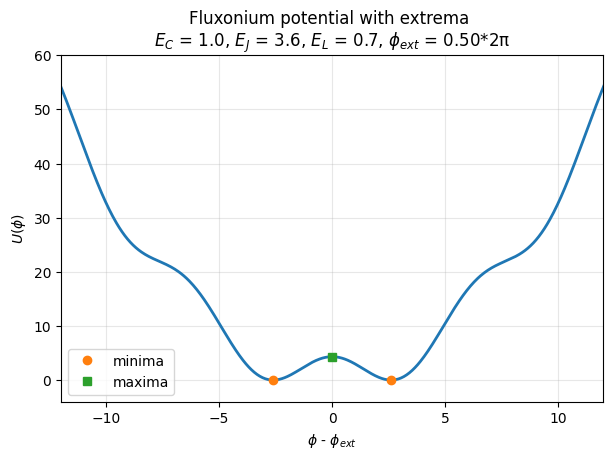

Minima phi: [[ 0.53215419 -0.71896861]
 [ 5.75103112 -0.71896861]]
Maxima phi: [[3.14159265 3.6       ]]


In [5]:
phi, U, minima, maxima, ax = plot_fluxonium_potential_with_extrema(
    param,
    phi_min=-3*np.pi,
    phi_max=10*np.pi,
    npoints= 1000,
    subtract_min=True,
)
plt.title(f'Fluxonium potential with extrema \n' \
rf'$E_C$ = {param.EC}, $E_J$ = {param.EJ}, $E_L$ = {param.EL}, $\phi_{{ext}}$ = {param.phi_ext0/ (2*np.pi):.2f}*2π')
plt.show()


print("Minima phi:", minima)
print("Maxima phi:", maxima)

## Fluxonium Driven Stroboscopic Poincare

$$
    H(t)=4E_C n^2+\frac{E_L}{2}\bigl(\phi-\varphi_{\mathrm{ext}}(t)\bigr)^2-E_J\cos\phi
    +\varepsilon_n\cos(\omega_d t)\,n
$$

In [7]:
# Initial conditions:
from fluxonium_classical import solve_with_work

print("Generating initial conditions...")
ics = make_initial_conditions(
    phi_min=-3*np.pi,
    phi_max= 3*np.pi,
    n_min=-6.0,
    n_max= 6.0,
    n_phi=10,
    n_n=8,
    random=True,
    seed=4,
)

t_eval = np.linspace(0.0, 5000.0, 1000)

Generating initial conditions...


### Run this cell to test the dynamics integration solver. 

In [8]:
ics_sel = [0, 1]  
atol =[1e-6, 1e-8, 1e-10]
rtol =[1e-8, 1e-10, 1e-12]

for i in range(len(ics_sel)):
    for j in range(len(atol)):
        print(f"Testing initial condition {i} with atol={atol[j]}, rtol={rtol[j]}...")
        u0 = ics[ics_sel[i]]
        sol = solve_with_work(
            u0=u0,
            t_span=(0.0, t_eval[-1]),
            p=param,
            t_eval=t_eval,
            method="DOP853",
            rtol=rtol[j],
            atol=atol[j],
        )

        diag = energy_balance_from_augmented_solution(sol, param)

        print("max abs error =", diag["max_abs_error"])
        print("rms error     =", diag["rms_error"])


Testing initial condition 0 with atol=1e-06, rtol=1e-08...
max abs error = 0.29397122949721677
rms error     = 0.16793332331959573
Testing initial condition 0 with atol=1e-08, rtol=1e-10...
max abs error = 0.001142454742677046
rms error     = 0.0006597323074352562
Testing initial condition 0 with atol=1e-10, rtol=1e-12...
max abs error = 5.694969956948626e-06
rms error     = 3.288233540468e-06
Testing initial condition 1 with atol=1e-06, rtol=1e-08...
max abs error = 0.03178671782480258
rms error     = 0.018470315223254895
Testing initial condition 1 with atol=1e-08, rtol=1e-10...
max abs error = 7.153253820746386e-05
rms error     = 4.129105208576601e-05
Testing initial condition 1 with atol=1e-10, rtol=1e-12...
max abs error = 1.193844296309976e-06
rms error     = 6.8969339962524e-07


### After testing the dynamics integration solver, we can run the following code to generate a Poincare section.

In [58]:
import sys
sys.path.append('../src')  # add the src directory to the Python path
from fluxonium_classical import FluxoniumParams, poincare_section, make_initial_conditions

# Initial conditions:
ics = make_initial_conditions(
    phi_min=-2*np.pi,
    phi_max= 2*np.pi,
    n_min=-2.0,
    n_max= 2.0,
    n_phi=10,
    n_n=10,
    random=True,
    seed=4,
)

# Poincare section at phase_fraction = 0.0
points = poincare_section(
    p=param,
    initial_conditions=ics,
    n_discard=0,
    n_strobes=200,
    phase_fraction=0.0,      # use 1/8 if you want a shifted strobe phase
    wrap_phi_for_plot=False, # keep unwrapped to see interwell transport
    method = "DOP853",
    rtol = 1e-8,
    atol = 1e-8,
)


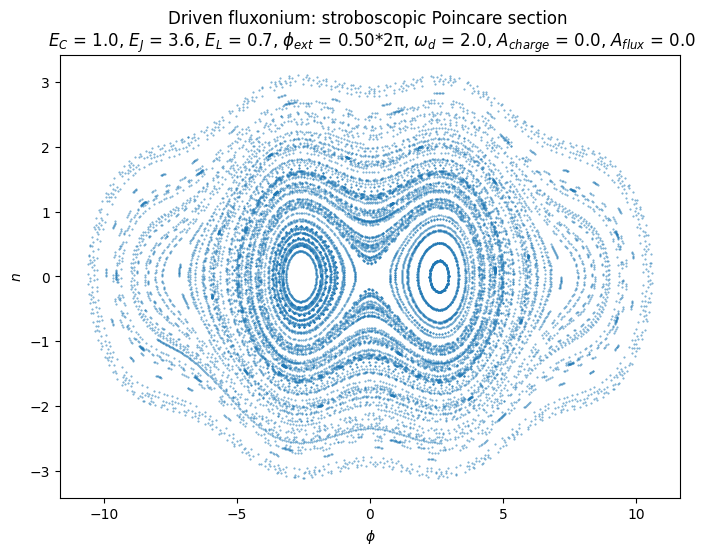

In [59]:
plt.figure(figsize=(7.0, 5.2))
plt.scatter(points[:, 0] - np.pi, points[:, 1], s=0.2, alpha=0.7, rasterized=True)
plt.xlabel(r"$\phi$")
plt.ylabel(r"$n$")
plt.tight_layout()
plt.title("Driven fluxonium: stroboscopic Poincare section \n " \
""rf"$E_C$ = {param.EC}, $E_J$ = {param.EJ}, $E_L$ = {param.EL}, $\phi_{{ext}}$ = {param.phi_ext0/ (2*np.pi):.2f}*2π, " \
""rf"$\omega_d$ = {param.omega_d}, $A_{{charge}}$ = {param.A_charge}, $A_{{flux}}$ = {param.A_flux}")
plt.show()

### Multiple plots for Driven system, changing drive amplitude

In [71]:
import sys
sys.path.append('../src')  # add the src directory to the Python path
from fluxonium_classical import FluxoniumParams, poincare_section, make_initial_conditions

A_charges = [0.0, 0.01, 0.05, 0.1]
pointss = []

for A_charge in A_charges:
    param = FluxoniumParams(
        EC=1.0,
        EJ=3.6,
        EL=0.7,
        phi_ext0= 0.5*2*np.pi,
        omega_d=2.0,
        A_charge=A_charge,
        A_flux=0.0,
    )
    display(param)
    # Initial conditions:
    ics = make_initial_conditions(
        phi_min=-2*np.pi,
        phi_max= 2*np.pi,
        n_min=-2.0,
        n_max= 2.0,
        n_phi=10,
        n_n=10,
        random=True,
        seed=4,
    )

    # Poincare section at phase_fraction = 0.0
    points = poincare_section(
        p=param,
        initial_conditions=ics,
        n_discard=0,
        n_strobes=200,
        phase_fraction=0.0,      # use 1/8 if you want a shifted strobe phase
        wrap_phi_for_plot=False, # keep unwrapped to see interwell transport
        method = "DOP853",
        rtol = 1e-8,
        atol = 1e-8,
    )
    pointss.append(points)



FluxoniumParams(EC=1.0, EJ=3.6, EL=0.7, phi_ext0=3.141592653589793, omega_d=2.0, A_charge=0.0, A_flux=0.0, gauge='inductive')

FluxoniumParams(EC=1.0, EJ=3.6, EL=0.7, phi_ext0=3.141592653589793, omega_d=2.0, A_charge=0.01, A_flux=0.0, gauge='inductive')

FluxoniumParams(EC=1.0, EJ=3.6, EL=0.7, phi_ext0=3.141592653589793, omega_d=2.0, A_charge=0.05, A_flux=0.0, gauge='inductive')

FluxoniumParams(EC=1.0, EJ=3.6, EL=0.7, phi_ext0=3.141592653589793, omega_d=2.0, A_charge=0.1, A_flux=0.0, gauge='inductive')

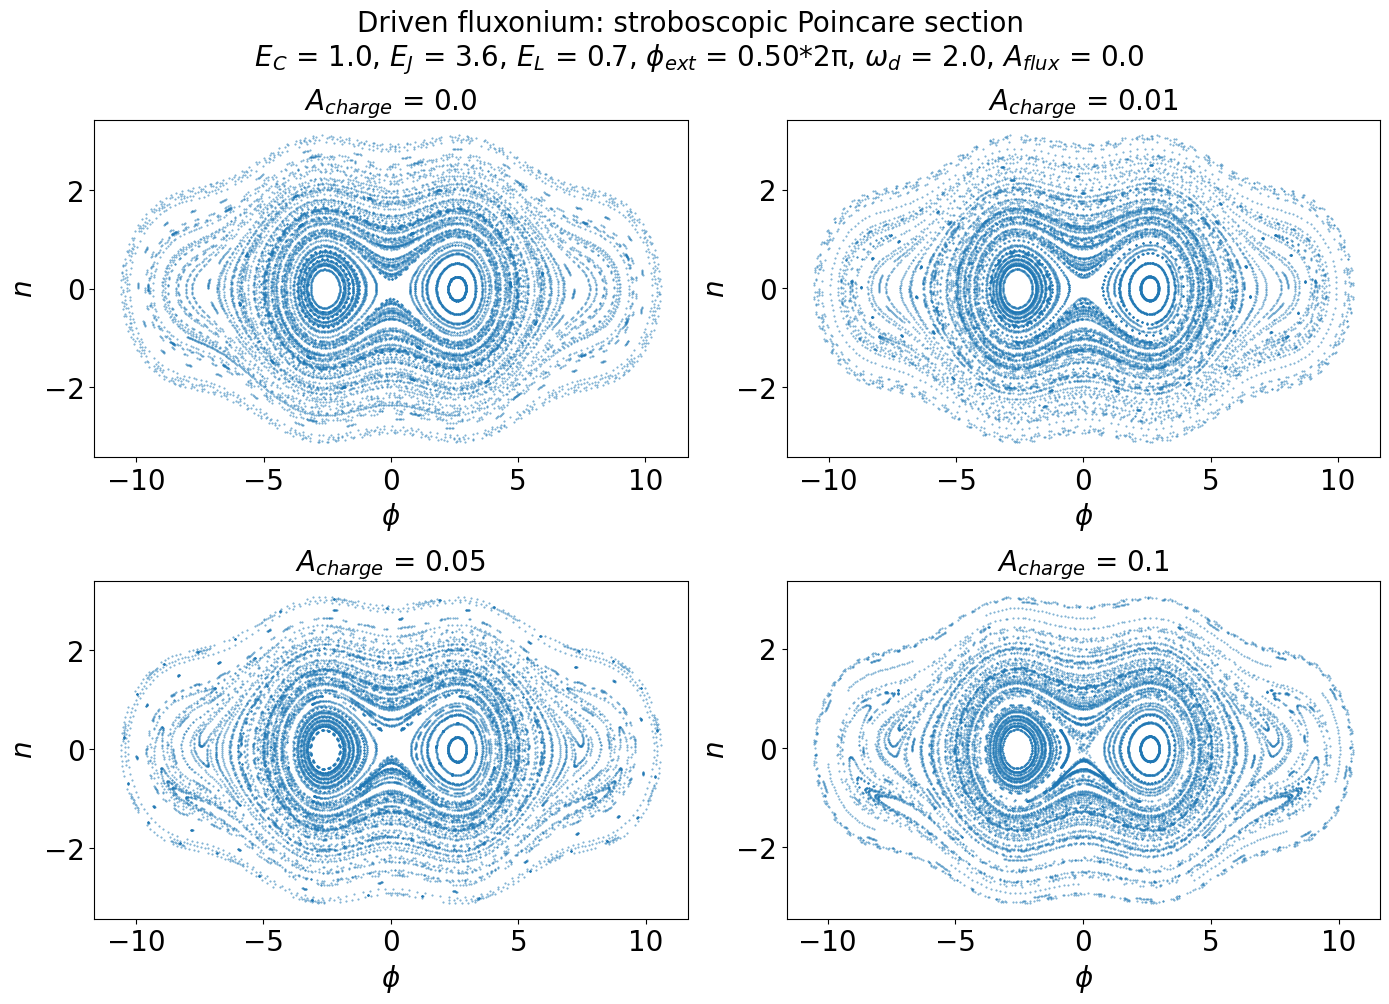

In [72]:
fig, axes = plt.subplots(2, 2, figsize=(14.0, 10.2))
axes = axes.flatten()  # flatten to iterate easily
plot_fontsize = 20

for i, A_charge in enumerate(A_charges):
    points = pointss[i]
    axes[i].scatter(points[:, 0] - np.pi, points[:, 1], s=0.2, alpha=0.7, rasterized=True)
    axes[i].set_xlabel(r"$\phi$", fontsize=plot_fontsize)
    axes[i].set_ylabel(r"$n$", fontsize=plot_fontsize)
    axes[i].set_title(f"$A_{{charge}}$ = {A_charge}", fontsize=plot_fontsize)
    axes[i].tick_params(axis='both', labelsize=plot_fontsize)

fig.suptitle("Driven fluxonium: stroboscopic Poincare section \n " \
""rf"$E_C$ = {param.EC}, $E_J$ = {param.EJ}, $E_L$ = {param.EL}, $\phi_{{ext}}$ = {param.phi_ext0/ (2*np.pi):.2f}*2π, " \
""rf"$\omega_d$ = {param.omega_d}, $A_{{flux}}$ = {param.A_flux}", fontsize=plot_fontsize)
plt.tight_layout()
plt.show()

In [67]:
import sys
sys.path.append('../src')  # add the src directory to the Python path
from fluxonium_classical import FluxoniumParams, poincare_section, make_initial_conditions

A_charges = [0.1, 0.5, 1.0, 5.0]
pointss = []

for A_charge in A_charges:
    param = FluxoniumParams(
        EC=1.0,
        EJ=3.6,
        EL=0.7,
        phi_ext0= 0.5*2*np.pi,
        omega_d=2.0,
        A_charge=A_charge,
        A_flux=0.0,
    )
    display(param)
    # Initial conditions:
    ics = make_initial_conditions(
        phi_min=-2*np.pi,
        phi_max= 2*np.pi,
        n_min=-2.0,
        n_max= 2.0,
        n_phi=10,
        n_n=10,
        random=True,
        seed=4,
    )

    # Poincare section at phase_fraction = 0.0
    points = poincare_section(
        p=param,
        initial_conditions=ics,
        n_discard=0,
        n_strobes=200,
        phase_fraction=0.0,      # use 1/8 if you want a shifted strobe phase
        wrap_phi_for_plot=False, # keep unwrapped to see interwell transport
        method = "DOP853",
        rtol = 1e-8,
        atol = 1e-8,
    )
    pointss.append(points)



FluxoniumParams(EC=1.0, EJ=3.6, EL=0.7, phi_ext0=3.141592653589793, omega_d=2.0, A_charge=0.1, A_flux=0.0, gauge='inductive')

FluxoniumParams(EC=1.0, EJ=3.6, EL=0.7, phi_ext0=3.141592653589793, omega_d=2.0, A_charge=0.5, A_flux=0.0, gauge='inductive')

FluxoniumParams(EC=1.0, EJ=3.6, EL=0.7, phi_ext0=3.141592653589793, omega_d=2.0, A_charge=1.0, A_flux=0.0, gauge='inductive')

FluxoniumParams(EC=1.0, EJ=3.6, EL=0.7, phi_ext0=3.141592653589793, omega_d=2.0, A_charge=5.0, A_flux=0.0, gauge='inductive')

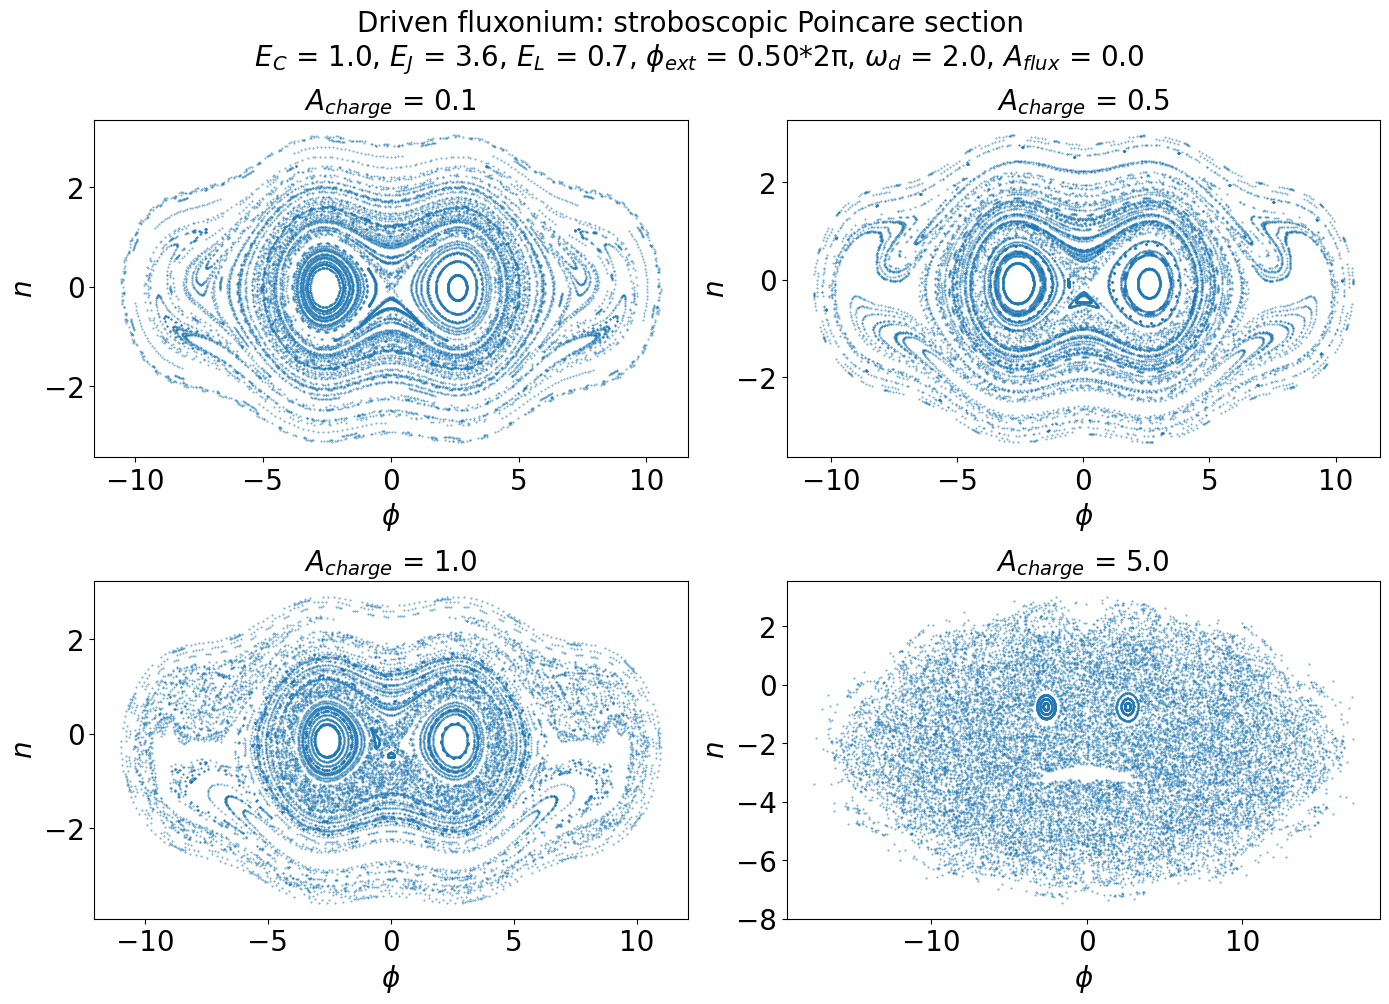

In [70]:
fig, axes = plt.subplots(2, 2, figsize=(14.0, 10.2))
axes = axes.flatten()  # flatten to iterate easily
plot_fontsize = 20

for i, A_charge in enumerate(A_charges):
    points = pointss[i]
    axes[i].scatter(points[:, 0] - np.pi, points[:, 1], s=0.2, alpha=0.7, rasterized=True)
    axes[i].set_xlabel(r"$\phi$", fontsize=plot_fontsize)
    axes[i].set_ylabel(r"$n$", fontsize=plot_fontsize)
    axes[i].set_title(f"$A_{{charge}}$ = {A_charge}", fontsize=plot_fontsize)
    axes[i].tick_params(axis='both', labelsize=plot_fontsize)

fig.suptitle("Driven fluxonium: stroboscopic Poincare section \n " \
""rf"$E_C$ = {param.EC}, $E_J$ = {param.EJ}, $E_L$ = {param.EL}, $\phi_{{ext}}$ = {param.phi_ext0/ (2*np.pi):.2f}*2π, " \
""rf"$\omega_d$ = {param.omega_d}, $A_{{flux}}$ = {param.A_flux}", fontsize=plot_fontsize)
plt.tight_layout()
plt.show()

### Multiple plots for Driven system, changing drive frequency

In [74]:
import sys
sys.path.append('../src')  # add the src directory to the Python path
from fluxonium_classical import FluxoniumParams, poincare_section, make_initial_conditions

omega_ds = [0.1, 1., 2., 3.0]
pointss = []

for omega_d in omega_ds:
    param = FluxoniumParams(
        EC=1.0,
        EJ=3.6,
        EL=0.7,
        phi_ext0= 0.5*2*np.pi,
        omega_d=omega_d,
        A_charge=0.1,
        A_flux=0.0,
    )
    display(param)
    # Initial conditions:
    ics = make_initial_conditions(
        phi_min=-2*np.pi,
        phi_max= 2*np.pi,
        n_min=-2.0,
        n_max= 2.0,
        n_phi=10,
        n_n=10,
        random=True,
        seed=4,
    )

    # Poincare section at phase_fraction = 0.0
    points = poincare_section(
        p=param,
        initial_conditions=ics,
        n_discard=0,
        n_strobes=200,
        phase_fraction=0.0,      # use 1/8 if you want a shifted strobe phase
        wrap_phi_for_plot=False, # keep unwrapped to see interwell transport
        method = "DOP853",
        rtol = 1e-8,
        atol = 1e-8,
    )
    pointss.append(points)



FluxoniumParams(EC=1.0, EJ=3.6, EL=0.7, phi_ext0=3.141592653589793, omega_d=0.1, A_charge=0.1, A_flux=0.0, gauge='inductive')

FluxoniumParams(EC=1.0, EJ=3.6, EL=0.7, phi_ext0=3.141592653589793, omega_d=1.0, A_charge=0.1, A_flux=0.0, gauge='inductive')

FluxoniumParams(EC=1.0, EJ=3.6, EL=0.7, phi_ext0=3.141592653589793, omega_d=2.0, A_charge=0.1, A_flux=0.0, gauge='inductive')

FluxoniumParams(EC=1.0, EJ=3.6, EL=0.7, phi_ext0=3.141592653589793, omega_d=3.0, A_charge=0.1, A_flux=0.0, gauge='inductive')

<>:10: SyntaxWarning: invalid escape sequence '\o'
<>:10: SyntaxWarning: invalid escape sequence '\o'
C:\Users\edson\AppData\Local\Temp\ipykernel_10888\3401250805.py:10: SyntaxWarning: invalid escape sequence '\o'
  axes[i].set_title(f"$\omega_{{d}}$ = {omega_d}", fontsize=plot_fontsize)


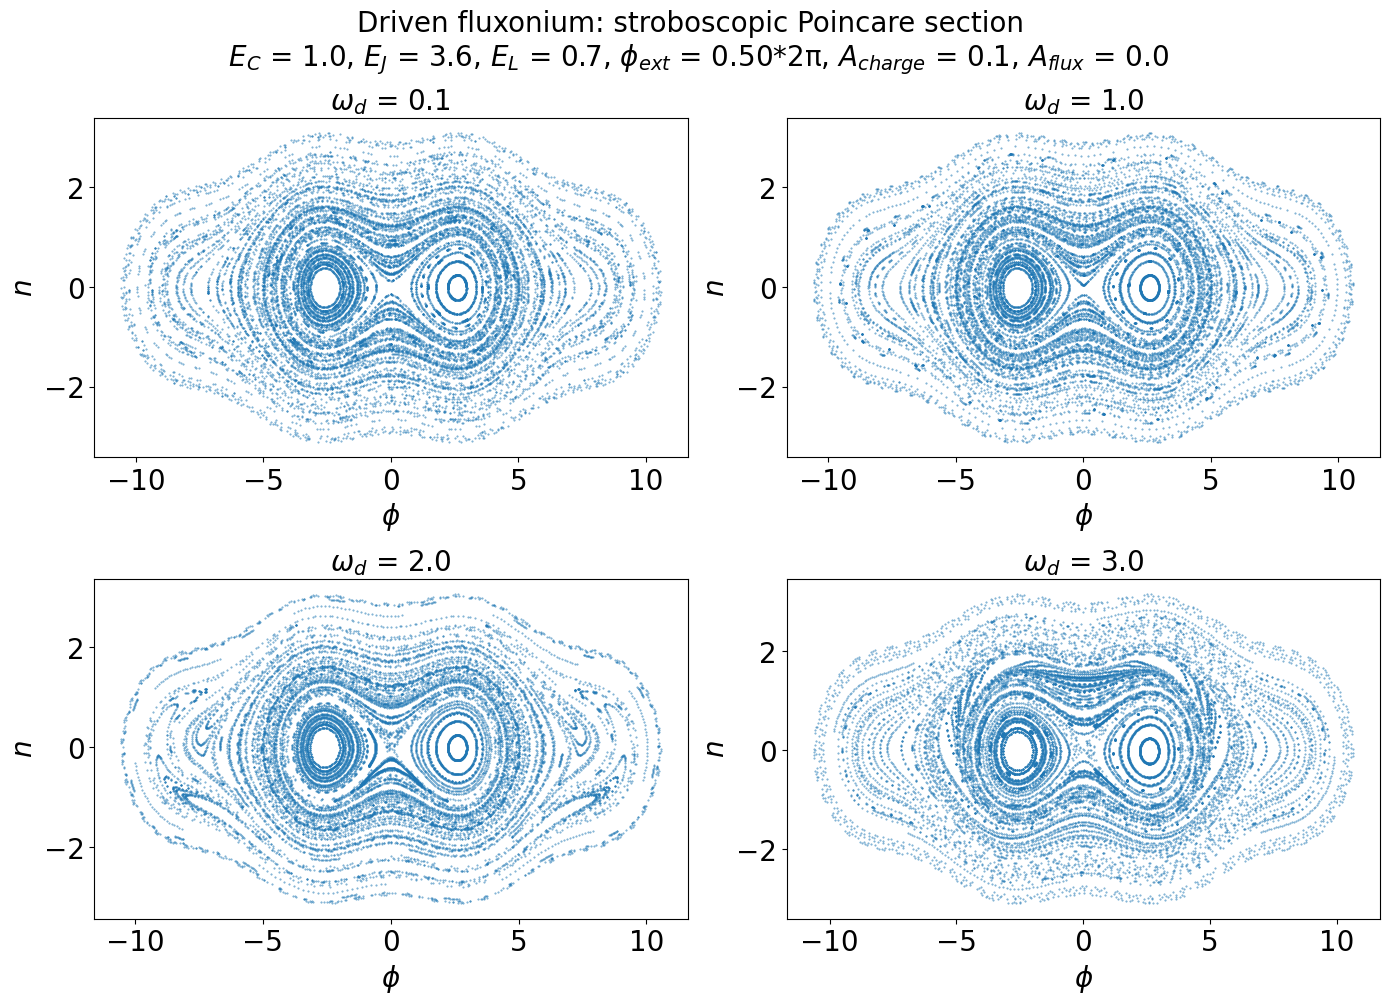

In [80]:
fig, axes = plt.subplots(2, 2, figsize=(14.0, 10.2))
axes = axes.flatten()  # flatten to iterate easily
plot_fontsize = 20

for i, omega_d in enumerate(omega_ds):
    points = pointss[i]
    axes[i].scatter(points[:, 0] - np.pi, points[:, 1], s=0.2, alpha=0.7, rasterized=True)
    axes[i].set_xlabel(r"$\phi$", fontsize=plot_fontsize)
    axes[i].set_ylabel(r"$n$", fontsize=plot_fontsize)
    axes[i].set_title(f"$\omega_{{d}}$ = {omega_d}", fontsize=plot_fontsize)
    axes[i].tick_params(axis='both', labelsize=plot_fontsize)

fig.suptitle("Driven fluxonium: stroboscopic Poincare section \n " \
""rf"$E_C$ = {param.EC}, $E_J$ = {param.EJ}, $E_L$ = {param.EL}, $\phi_{{ext}}$ = {param.phi_ext0/ (2*np.pi):.2f}*2π, " \
""rf"$A_{{charge}}$ = {param.A_charge}, $A_{{flux}}$ = {param.A_flux}", fontsize=plot_fontsize)
plt.tight_layout()
plt.show()